# Tutorial 04: DEXPI, FAIR & AI-ready Process Systems Engineering Data

Welcome! This notebook is the **first step** of a two-part tutorial that
introduces you to **FAIR Research Data Management (RDM)** in process systems
engineering using the [DEXPI](https://dexpi.org/) standard.

> **No prior knowledge of DEXPI, knowledge graphs or RDM is required.**
> If you know basic Python, you'll be fine.

## Learning Goals

After completing this notebook you will be able to:

1. Explain the **FAIR** principles (*Findable, Accessible,
   Interoperable, Reusable*) in your own words
2. Describe **why DEXPI** P&ID files are a great example of introperable,
   reusable and AI-ready engineering data
3. **Load** a Proteus XML DEXPI file with `pyDEXPI` and explore its content
4. **Serialize** the model to JSON for downstream use
5. Build a **knowledge graph** from the plant

## 🔢 Example Dataset

We will work with the official *DEXPI 1.3 Reference P&ID*
[`C01V04-VER.EX01.xml`](../data/dexpi/C01V04-VER.EX01.xml), shipped in this
repository under [data/dexpi/](../data/dexpi/). It depicts a small chemical
plant with heat exchangers, pumps, a tank and instrumentation.


## 1 Recapitulation of FAIR Principles & DEXPI

### The FAIR principles

Research data should be **F**indable, **A**ccessible, **I**nteroperable and
**R**eusable — by **humans *and* machines**. Concretely:

| Letter            | Means                                                   | On the example dataset                                |
|-------------------|---------------------------------------------------------|-------------------------------------------------------|
| **F**indable      | Has a unique, persistent identifier and rich metadata   |  |
| **A**ccessible    | Can be retrieved using open, free protocols             | Files are plain XML/JSON, not vendor-locked binaries  |
| **I**nteroperable | Uses shared vocabularies / standards                    | DEXPI is a **community standard** (ISO 15926-derived) |
| **R**eusable      | Has a clear license & provenance metadata               |  |

### Why DEXPI?

A traditional P&ID is just a *picture* — a PDF or DWG that humans can read
but computers cannot. **DEXPI** ("Data Exchange in the Process Industry")
defines a *semantic data model* of plant items, piping and instrumentation,
serialised as a **Proteus XML** file. That means:

- **AI-ready**: equipment, nozzles, pipes and signals are typed objects
  with unambiguous relationships → directly usable by ML pipelines.
- **Interoperable**: a Siemens COMOS export and an AVEVA Diagrams export
  describe the same plant in the same way.
- **Reusable**: you can re-render the diagram, re-build the graph, or
  link operational data to it — years from now, with open-source tools.

This is exactly what the [`pyDEXPI`](https://github.com/process-intelligence-research/pyDEXPI)
library lets us do in Python.


## 2 Setup

If you followed the [README](../README.md) and ran `uv sync`, all packages
are already installed in `.venv`. The cell below just makes the project root
importable and prints the versions you'll be using.


In [ ]:
# Import and load needed libraries and modules
from pathlib import Path

import networkx as nx
import pydexpi

# Resolve the project root no matter where the notebook is launched from
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DEXPI_DIR = PROJECT_ROOT / "data" / "dexpi"
DEXPI_FILE = "C01V04-VER.EX01.xml"

print(f"Project root : {PROJECT_ROOT}")
print(f"DEXPI file   : {DEXPI_DIR / DEXPI_FILE}  (exists={ (DEXPI_DIR / DEXPI_FILE).exists()})")
print(f"pyDEXPI      : v{pydexpi.__version__ if hasattr(pydexpi, '__version__') else 'unknown'}")
print(f"NetworkX     : v{nx.__version__}")

Project root : /Users/niklas-maximilianepping/Projekte/PSE-KG
DEXPI file   : /Users/niklas-maximilianepping/Projekte/PSE-KG/data/dexpi/C01V04-VER.EX01.xml  (exists=True)
pyDEXPI      : vunknown
NetworkX     : v3.5


## 3 Loading a DEXPI Proteus XML file

DEXPI ships with a serializer for **Proteus XML**, the official DEXPI
exchange format. `pyDEXPI` reads that XML and converts it into a tree of
typed Python objects (Pydantic models). 

> 🧠 **Why Pydantic?** Pydantic enforces the DEXPI schema — for example
> you cannot accidentally attach a *Pump* as a *Nozzle* of a *Tank*. This
> built-in validation is one reason DEXPI data is *AI-ready*: every object
> has a known type and known relationships.


In [22]:
from pydexpi.loaders import ProteusSerializer

loader = ProteusSerializer()
dexpi_model = loader.load(str(DEXPI_DIR), DEXPI_FILE)

print(f"Loaded model of type : {type(dexpi_model).__name__}")
print(f"Originating system   : {dexpi_model.originatingSystemName} "
      f"v{dexpi_model.originatingSystemVersion}")
print(f"Exported on          : {dexpi_model.exportDateTime}")
print(f"Model UUID           : {dexpi_model.id}")


Loaded model of type : DexpiModel
Originating system   : P&ID Toolbox v1.1.0
Exported on          : 2022-11-04 20:30:49.613610
Model UUID           : 44f18b60-b5f5-40d9-bd63-a035c0ece819


### 3.1 Inspecting the conceptual model

The `conceptualModel` is the heart of a DEXPI file: it lists *what* the
plant is made of (without caring about graphical positions). Let's count
its main collections.


In [23]:
cm = dexpi_model.conceptualModel

summary = {
    "Tagged plant items (equipment)": len(cm.taggedPlantItems),
    "Piping network systems":          len(cm.pipingNetworkSystems),
    "Process instrumentation funcs":   len(cm.processInstrumentationFunctions),
    "Actuating systems":               len(cm.actuatingSystems),
    "Plant structure items":           len(cm.plantStructureItems),
}
for k, v in summary.items():
    print(f"  {k:35s} {v}")


  Tagged plant items (equipment)      5
  Piping network systems              11
  Process instrumentation funcs       4
  Actuating systems                   3
  Plant structure items               0


### 3.2 Listing the equipment

Each piece of equipment carries a **tag name** (the human label, e.g.
`P4711`) *and* an automatically assigned UUID. That dual identity is a
small but powerful FAIR feature — humans use the tag, machines use the
UUID, and both are persistent.


In [24]:
import pandas as pd

equipment_records = [
    {
        "tag":  item.tagName,
        "type": type(item).__name__,
        "uuid": item.id,
        "n_nozzles": len(getattr(item, "nozzles", []) or []),
    }
    for item in cm.taggedPlantItems
]

equipment_df = pd.DataFrame(equipment_records)
equipment_df


,tag,type,uuid,n_nozzles
0,H1007,PlateHeatExchanger,40f6f49d-dfc5-4be2-a991-450a267e3e47,4
1,H1008,TubularHeatExchanger,d213148f-316d-472a-ba57-9fde4ef751ff,4
2,P4711,CentrifugalPump,72e69d9f-0f8e-4a63-a45d-64991cf16309,2
3,P4712,ReciprocatingPump,b6faa492-00e1-4aa5-874b-e4dbde24a2a1,2
4,T4750,Tank,f4ce8c0d-cb30-4dab-8b98-932943c9cf0e,7


## 4 Serialising the model to JSON

XML is great for exchange, but JSON is much friendlier for downstream
tooling, dashboards or AI pipelines. `pyDEXPI` ships a JSON serializer
that round-trips with no information loss.

> **FAIR perspective:** by writing the model out as JSON, we make it
> *Accessible* through any HTTP / file system without specialised
> P&ID tooling and *Interoperable* with the entire JSON ecosystem.


In [ ]:
from pydexpi.loaders import JsonSerializer

JSON_DIR = PROJECT_ROOT / "data" / "json"
JSON_DIR.mkdir(parents=True, exist_ok=True)

json_serializer = JsonSerializer()
json_serializer.save(dexpi_model, str(JSON_DIR), "C01V04-VER.EX01")

json_path = JSON_DIR / "C01V04-VER.EX01.json"
print(f"   JSON written to: {json_path.relative_to(PROJECT_ROOT)}")
print(f"   File size      : {json_path.stat().st_size / 1024:.1f} KB")

✅ JSON written to: data/json/C01V04-VER.EX01.json
   File size      : 2093.0 KB


## 5 Building a knowledge graph with `pyDEXPI`

A graph is a natural representation of a P&ID: every piece of equipment,
every nozzle, every pipe is a **node**, and every connection is an
**edge**. `pyDEXPI` provides three levels of abstraction:

| Method | Output | Typical use |
|--------|--------|-------------|
| `GraphLoader.parse_dexpi_to_graph` | **Plant graph** — every DEXPI object is a node | Lossless analysis, debugging |
| `GraphAbstractor.build_process_graph` | **Process graph** — piping internals collapsed into pipes | Topology analysis, ML features |
| `GraphAbstractor.build_conceptual_graph` | **Conceptual graph** — equipment + signals only | High-level overview, RO-Crate, LLMs |

We'll build all three and compare their sizes.


In [26]:
from pydexpi.loaders import GraphLoader, GraphAbstractor

graph_loader = GraphLoader()
plant_graph      = graph_loader.parse_dexpi_to_graph(dexpi_model)
process_graph    = GraphAbstractor.build_process_graph(plant_graph)
conceptual_graph = GraphAbstractor.build_conceptual_graph(plant_graph)

graphs = {
    "Plant graph (lossless)":   plant_graph,
    "Process graph":            process_graph,
    "Conceptual graph":         conceptual_graph,
}

pd.DataFrame(
    [(name, g.number_of_nodes(), g.number_of_edges()) for name, g in graphs.items()],
    columns=["Abstraction level", "# nodes", "# edges"],
)


,Abstraction level,# nodes,# edges
0,Plant graph (lossless),214,376
1,Process graph,66,78
2,Conceptual graph,36,39


### 5.1 A static look (matplotlib)

Before going interactive, a quick static plot of the **conceptual graph**
gives an overview of the plant's topology. We colour-code the nodes by
DEXPI label.


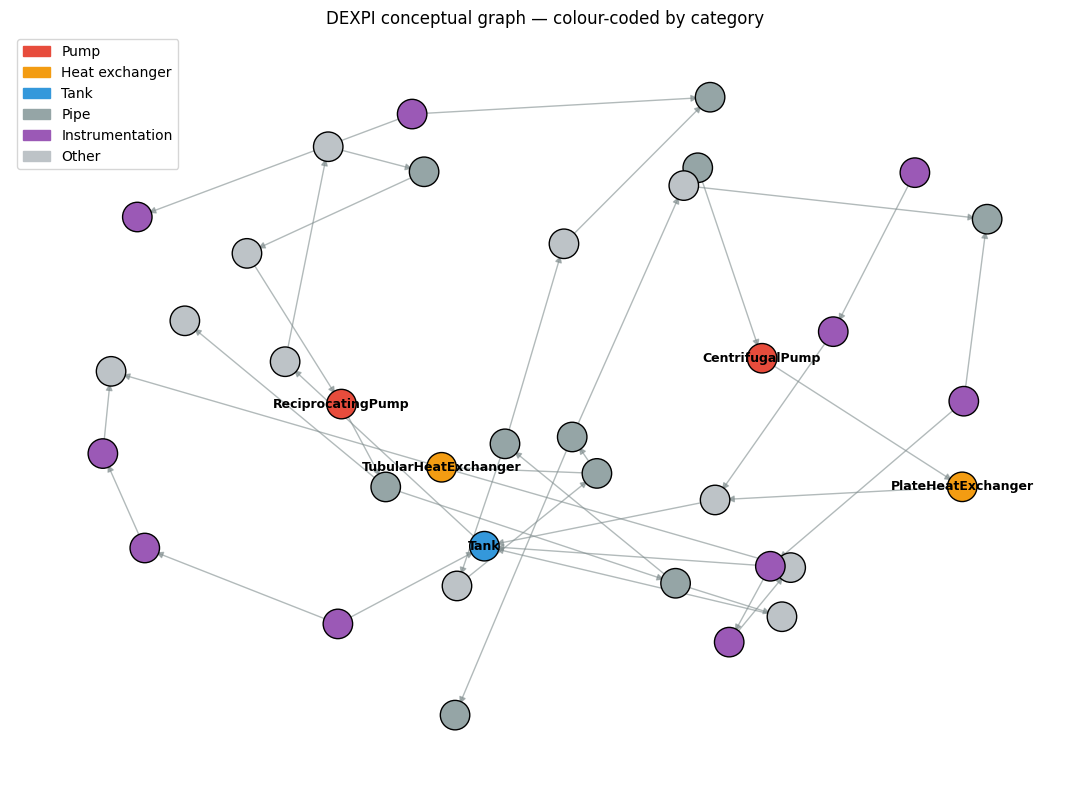

In [27]:
import matplotlib.pyplot as plt

def node_label(data: dict) -> str:
    """Pretty short label for plotting."""
    return data.get("label") or data.get("tagName") or "?"

def node_category(data: dict) -> str:
    """Coarse category used for colouring."""
    labels = data.get("labels") or data.get("label") or ""
    if "Pump"            in labels: return "Pump"
    if "HeatExchanger"   in labels: return "Heat exchanger"
    if "Tank"            in labels: return "Tank"
    if "Pipe"            in labels: return "Pipe"
    if "Instrument" in labels or "Signal" in labels: return "Instrumentation"
    return "Other"

palette = {
    "Pump":            "#e74c3c",
    "Heat exchanger":  "#f39c12",
    "Tank":            "#3498db",
    "Pipe":            "#95a5a6",
    "Instrumentation": "#9b59b6",
    "Other":           "#bdc3c7",
}

categories = [node_category(d) for _, d in conceptual_graph.nodes(data=True)]
colors     = [palette[c] for c in categories]

fig, ax = plt.subplots(figsize=(11, 8))
pos = nx.spring_layout(conceptual_graph, seed=42, k=0.6)
nx.draw_networkx_edges(conceptual_graph, pos, ax=ax, edge_color="#7f8c8d",
                       arrows=True, arrowsize=10, alpha=0.6)
nx.draw_networkx_nodes(conceptual_graph, pos, ax=ax,
                       node_color=colors, node_size=450, edgecolors="black")

# Only label tagged equipment to keep things readable
labels = {n: node_label(d) for n, d in conceptual_graph.nodes(data=True)
          if node_category(d) in {"Pump", "Heat exchanger", "Tank"}}
nx.draw_networkx_labels(conceptual_graph, pos, labels=labels, font_size=9,
                        font_weight="bold")

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=k) for k, c in palette.items()],
          loc="upper left", frameon=True)
ax.set_title("DEXPI conceptual graph — colour-coded by category")
ax.set_axis_off()
plt.tight_layout()
plt.show()


### 5.2 Interactive exploration with `pyvis`

Static plots are nice, but a real P&ID has dozens (or thousands!) of items.
[`pyvis`](https://pyvis.readthedocs.io/) wraps the JavaScript library
[vis-network](https://visjs.github.io/vis-network/) so we can pan, zoom and
**hover over nodes** to read their full DEXPI metadata — directly inside
the notebook.


In [28]:
import os
from pyvis.network import Network
from IPython.display import IFrame
import html

OUTPUT_DIR = PROJECT_ROOT / "data" / "graphs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
html_path = OUTPUT_DIR / "conceptual_graph.html"


def build_interactive(graph, output_file: Path) -> Path:
    """Render a NetworkX graph to a self-contained interactive HTML file."""
    net = Network(
        height="600px", width="100%",
        directed=True, bgcolor="#ffffff", font_color="#222",
        notebook=False, cdn_resources="in_line",
    )
    # Slightly less aggressive physics for nicer layout
    net.barnes_hut(spring_length=120, gravity=-2500, central_gravity=0.2)

    for node, data in graph.nodes(data=True):
        cat   = node_category(data)
        label = data.get("tagName") or node_label(data)

        # Build a tooltip showing the most informative DEXPI attributes
        tooltip_lines = [f"<b>{html.escape(str(label))}</b>",
                         f"<i>{html.escape(cat)}</i>",
                         f"UUID: {node}"]
        for key in ("labels", "label_description", "fluidCode",
                    "nominalDiameterRepresentation", "pipingClassCode"):
            if key in data and data[key]:
                tooltip_lines.append(f"{key}: {html.escape(str(data[key]))}")

        net.add_node(
            node,
            label=str(label) if cat in {"Pump", "Heat exchanger", "Tank"} else "",
            title="<br>".join(tooltip_lines),
            color=palette[cat],
            shape="dot",
            size=24 if cat in {"Pump", "Heat exchanger", "Tank"} else 14,
        )

    for u, v, data in graph.edges(data=True):
        tooltip = "<br>".join(
            f"{k}: {html.escape(str(val))}" for k, val in data.items()
            if val is not None and k not in {"collapsed_from", "stitched_from",
                                              "collapsed_node_id"}
        )
        net.add_edge(u, v, title=tooltip, color="#7f8c8d")

    output_file.parent.mkdir(parents=True, exist_ok=True)
    net.write_html(str(output_file), notebook=False, open_browser=False)
    return output_file


html_path = build_interactive(conceptual_graph, html_path)
print(f"📄 Interactive graph written to: {html_path.relative_to(PROJECT_ROOT)}")

# Display directly inside the notebook (path relative to where the notebook runs)
iframe_src = os.path.relpath(html_path, start=Path.cwd())
IFrame(src=iframe_src, width="100%", height=620)


📄 Interactive graph written to: data/graphs/conceptual_graph.html


> 💡 **Try it out:** drag the nodes around, hover over any node or edge to
> read the underlying DEXPI metadata. The HTML file is **self-contained**
> so you can share it with colleagues — they don't need Python installed.

## 6 Bonus: render the original P&ID as SVG

`pyDEXPI` can also re-draw the original P&ID as an **SVG**, directly from
the same model object. SVG is a vector format, so the diagram remains crisp
at any zoom level — perfect for publications and reports.


🖼  SVG written to: data/graphs/C01V04-VER.EX01.svg (114.4 KB)


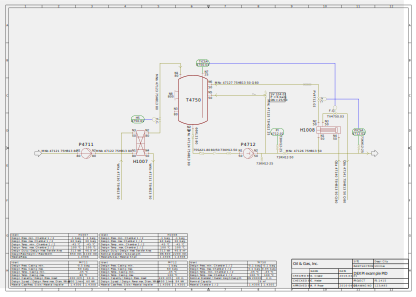

In [29]:
from pydexpi.loaders.svg_loader import DrawDiagram
from IPython.display import SVG

svg_dir = OUTPUT_DIR
svg_dir.mkdir(parents=True, exist_ok=True)

drawer = DrawDiagram(dexpi_model.diagram, padding=5.0, pretty=True)
# Signature: save_svg(object_name, filepath, background=True)
saved_path = drawer.save_svg("C01V04-VER.EX01", str(svg_dir))

svg_file = Path(saved_path)
print(f"🖼  SVG written to: {svg_file.relative_to(PROJECT_ROOT)} "
      f"({svg_file.stat().st_size/1024:.1f} KB)")
SVG(filename=str(svg_file))


## 7 Recap & where to go next

In this notebook you have:

- Learned what **FAIR data** means in a process-engineering context.  
- Loaded a **DEXPI Proteus XML** file with `pyDEXPI`.  
- Inspected typed equipment objects (Pumps, Heat Exchangers, Tanks, …).  
- Re-serialised the model to **JSON** for downstream tools.  
- Built three levels of **knowledge graph** from the same model.  
- Generated an **interactive HTML graph** and a publication-grade **SVG**.

You now have artefacts that are *Findable* (UUIDs everywhere), *Accessible*
(open formats), *Interoperable* (standards-based), and almost *Reusable* —
the missing piece is **provenance & context**: who produced this data,
under which experiment, with which sensors and analyses?

That's exactly what **Tutorial 2** addresses by packaging everything into a
**Research Object Crate (RO-Crate)**.

➡️ Continue with [02_ro_crate_from_dexpi.ipynb](02_ro_crate_from_dexpi.ipynb).

### Further reading

- DEXPI standard: <https://dexpi.org/>
- pyDEXPI: <https://github.com/process-intelligence-research/pyDEXPI>
- FAIR principles (Wilkinson et al., 2016): <https://www.go-fair.org/fair-principles/>
- DEXPI 1.3 reference P&ID: <https://gitlab.com/dexpi/TrainingTestCases>
